In [1]:
from pathlib import Path
import os
import sys

# move working directory to project root (parent of notebooks)
project_root = Path.cwd().parent
os.chdir(project_root)

# ensure imports work
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Working directory:", Path.cwd())

Working directory: /mnt/c/Research/LLMAgora


In [2]:
from agora.sweep_results import SweepManifest

manifest = SweepManifest.from_path("outputs/sweeps/manifest.json")

In [3]:
type(manifest)

agora.sweep_results.SweepManifest

In [4]:
from agora.experiment import SEMANTIC_ANALYSIS_METRICS
from agora.persona_adherence_evaluator import PERSONA_ANALYSIS_METRICS

# Run all available analyses on every repeat of one experiment group
results = manifest[0].run_analysis(
    manifest.sweep_root,
    semantic_analysis_metrics=list(SEMANTIC_ANALYSIS_METRICS),
    persona_analysis_metrics=list(PERSONA_ANALYSIS_METRICS),
)

# Or on a single case
result = manifest[0].cases[0].run_analysis(
    manifest.sweep_root,
    semantic_analysis_metrics=list(SEMANTIC_ANALYSIS_METRICS),
    persona_analysis_metrics=list(PERSONA_ANALYSIS_METRICS),
)


/home/snoroozi/anaconda3/envs/agora_eval/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
result

ExperimentResult(agora=<agora.agora.Agora object at 0x7ba4b955c400>, agents=[<agora.agent.Agent object at 0x7ba4b955f370>, <agora.agent.Agent object at 0x7ba4b955f7c0>], eval_data={'semantic_similarity': {'self_consistency': {'Alpha': {'turns': [1, 2], 'scores': [0.7151681184768677, 0.6369628310203552]}, 'Beta': {'turns': [1, 2], 'scores': [0.5986881256103516, 0.6734954714775085]}}, 'cross_agent_public_alignment': {'turns': [1, 2], 'scores': [0.5465877056121826, 0.7408245205879211]}, 'cross_agent_private_alignment': {'turns': [1, 2], 'scores': [0.4990538954734802, 0.6206711530685425]}}, 'persona_adherence': {'alpha': {'persona_id': 'mid_level_manager', 'computed_metrics': ['full_debate_private', 'full_debate_public', 'private_cumulative', 'private_per_turn', 'public_cumulative', 'public_per_turn'], 'public_per_turn_scores': {'turns': [1, 2], 'scores': {'mean': [5.0, 5.0], 'std': [0.0, 0.0], 'raw': [[5], [5]]}}, 'private_per_turn_scores': {'turns': [1, 2], 'scores': {'mean': [5.0, 5.0],

In [6]:
#  Text summary:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
import pprint

%matplotlib inline

# ── Helpers ───────────────────────────────────────────────────────────────────

def _fmt(v):
    """Round floats for display."""
    return f"{v:.3f}" if isinstance(v, float) else str(v)

alpha_agent, beta_agent = result.agents[0], result.agents[1]
alpha_name, beta_name = alpha_agent.name, beta_agent.name

sem  = result.eval_data.get("semantic_similarity", {})
pers = result.eval_data.get("persona_adherence")

# ── 1. Case summary ───────────────────────────────────────────────────────────
print("=" * 60)
print("EXPERIMENT RESULT SUMMARY")
print("=" * 60)
print(f"  Run dir  : {result.run_dir}")
print(f"  Agent α  : {alpha_name}  (id: {alpha_agent.id})")
print(f"  Agent β  : {beta_name}  (id: {beta_agent.id})")
print()

# ── 2. Semantic similarity — numeric summary ──────────────────────────────────
print("-" * 60)
print("SEMANTIC SIMILARITY  (scores in [0, 1]; higher = more similar)")
print("-" * 60)

sc = sem.get("self_consistency")
if sc:
    print("\n● Self-Consistency  (private narrative vs public utterance per turn)")
    print("  Measures whether each agent 'says what it thinks'.")
    for agent_id, data in sc.items():
        scores = data["scores"]
        turns  = data["turns"]
        pairs  = ", ".join(f"T{t}={_fmt(s)}" for t, s in zip(turns, scores))
        mean   = sum(scores) / len(scores)
        print(f"    {agent_id:30s}  {pairs}  → mean={_fmt(mean)}")
else:
    print("  self_consistency: not computed")

cpa = sem.get("cross_agent_public_alignment")
if cpa:
    scores = cpa["scores"]
    turns  = cpa["turns"]
    pairs  = ", ".join(f"T{t}={_fmt(s)}" for t, s in zip(turns, scores))
    mean   = sum(scores) / len(scores)
    print(f"\n● Cross-Agent Public Alignment  (how similar their public statements are per turn)")
    print(f"  High = converging; low = diverging.")
    print(f"    {pairs}  → mean={_fmt(mean)}")
else:
    print("\n  cross_agent_public_alignment: not computed")

cpriva = sem.get("cross_agent_private_alignment")
if cpriva:
    scores = cpriva["scores"]
    turns  = cpriva["turns"]
    pairs  = ", ".join(f"T{t}={_fmt(s)}" for t, s in zip(turns, scores))
    mean   = sum(scores) / len(scores)
    print(f"\n● Cross-Agent Private Alignment  (private thoughts — do they secretly agree?)")
    print(f"    {pairs}  → mean={_fmt(mean)}")
else:
    print("\n  cross_agent_private_alignment: not computed")

# ── 3. Persona adherence — numeric summary ───────────────────────────────────
print()
print("-" * 60)
print("PERSONA ADHERENCE  (LLM-judge scores 1-5; higher = more in-character)")
print("-" * 60)
if pers:
    for role, agent_name in (("alpha", alpha_name), ("beta", beta_name)):
        agent_pers = pers.get(role, {})
        computed   = agent_pers.get("computed_metrics", [])
        print(f"\n● {agent_name}  (computed: {computed})")

        fd_pub = agent_pers.get("full_debate_public_score", {})
        if fd_pub.get("mean") is not None:
            print(f"    Full-debate public  : mean={_fmt(fd_pub['mean'])}  std={_fmt(fd_pub['std'])}")

        fd_priv = agent_pers.get("full_debate_private_score", {})
        if fd_priv.get("mean") is not None:
            print(f"    Full-debate private : mean={_fmt(fd_priv['mean'])}  std={_fmt(fd_priv['std'])}")
else:
    print("  persona_adherence: not computed")

print()
print("=" * 60)

EXPERIMENT RESULT SUMMARY
  Run dir  : /mnt/c/Research/LLMAgora/outputs/sweeps/cases/525efd375f29
  Agent α  : Alpha  (id: 1d7c1308-36c5-4d71-b30a-b49766968f15)
  Agent β  : Beta  (id: 1f0a0354-5cc5-4490-bb92-3ad4bacd3a4a)

------------------------------------------------------------
SEMANTIC SIMILARITY  (scores in [0, 1]; higher = more similar)
------------------------------------------------------------

● Self-Consistency  (private narrative vs public utterance per turn)
  Measures whether each agent 'says what it thinks'.
    Alpha                           T1=0.715, T2=0.637  → mean=0.676
    Beta                            T1=0.599, T2=0.673  → mean=0.636

● Cross-Agent Public Alignment  (how similar their public statements are per turn)
  High = converging; low = diverging.
    T1=0.547, T2=0.741  → mean=0.644

● Cross-Agent Private Alignment  (private thoughts — do they secretly agree?)
    T1=0.499, T2=0.621  → mean=0.560

------------------------------------------------------

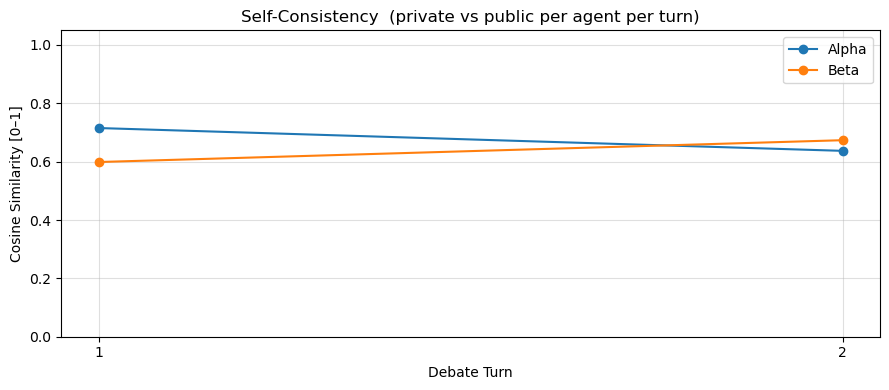

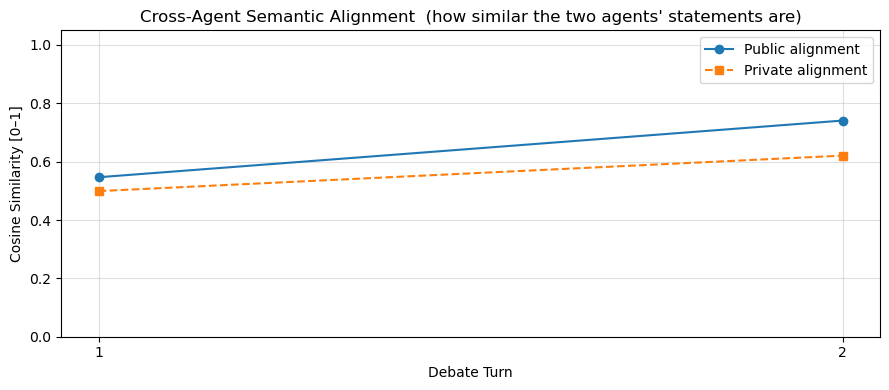

In [7]:
# ── 4. Semantic similarity plots ──────────────────────────────────────────────

def _int_xticks(ax, *turn_lists):
    all_turns = sorted({int(t) for ts in turn_lists for t in ts})
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
    if all_turns:
        ax.set_xticks(all_turns)

# Self-consistency
sc = sem.get("self_consistency")
if sc:
    fig, ax = plt.subplots(figsize=(9, 4))
    for agent_id, data in sc.items():
        ax.plot(data["turns"], data["scores"], marker="o", label=agent_id)
    _int_xticks(ax, *[d["turns"] for d in sc.values()])
    ax.set_title("Self-Consistency  (private vs public per agent per turn)")
    ax.set_xlabel("Debate Turn")
    ax.set_ylabel("Cosine Similarity [0–1]")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

# Cross-agent alignment
cpa    = sem.get("cross_agent_public_alignment")
cpriva = sem.get("cross_agent_private_alignment")
if cpa or cpriva:
    fig, ax = plt.subplots(figsize=(9, 4))
    if cpa:
        ax.plot(cpa["turns"],    cpa["scores"],    marker="o", label="Public alignment")
    if cpriva:
        ax.plot(cpriva["turns"], cpriva["scores"], marker="s", label="Private alignment", linestyle="--")
    _int_xticks(ax, (cpa or cpriva)["turns"])
    ax.set_title("Cross-Agent Semantic Alignment  (how similar the two agents' statements are)")
    ax.set_xlabel("Debate Turn")
    ax.set_ylabel("Cosine Similarity [0–1]")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

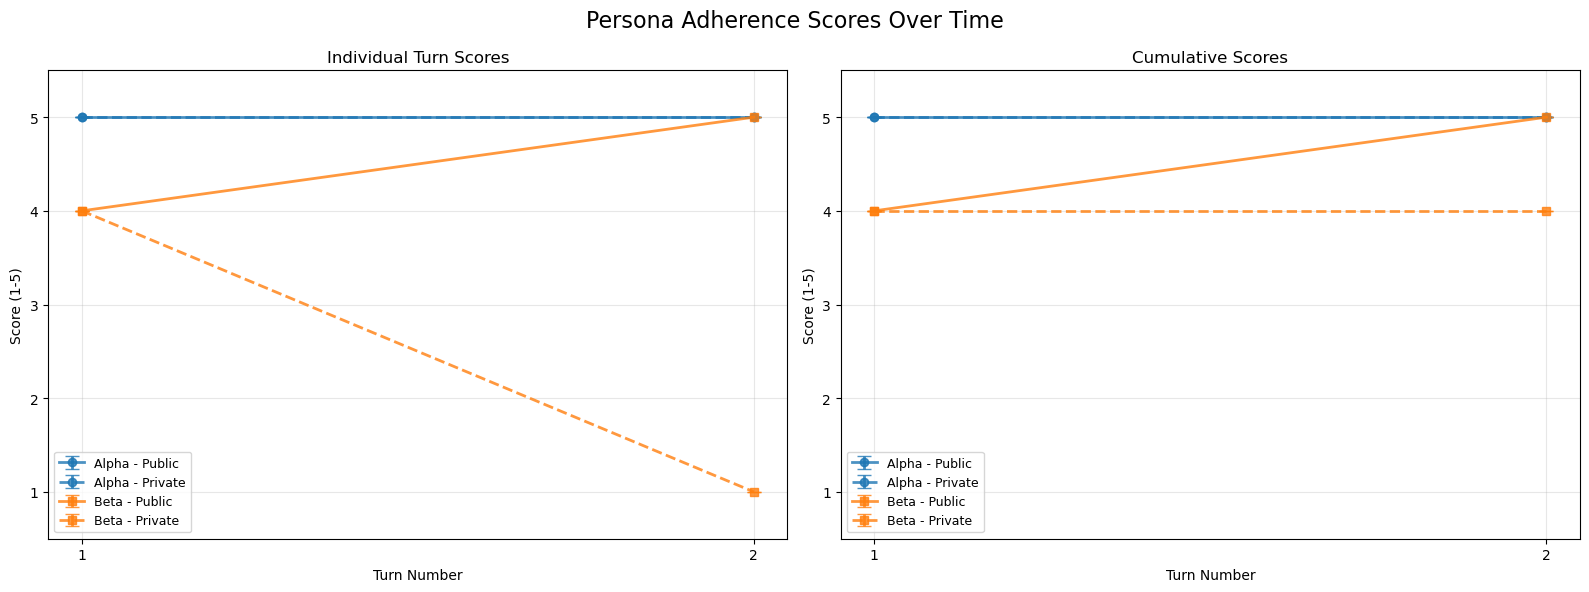

In [8]:
# Persona adherence plot:
# ── 5. Persona adherence plot ─────────────────────────────────────────────────
from agora.plotting import plot_persona_adherence

if pers:
    plot_persona_adherence(
        eval_dict=pers,
        alpha_persona_name=alpha_name,
        beta_persona_name=beta_name,
        save_path=None,
        show_plot=True,
    )
else:
    print("No persona adherence data to plot.")

Loading nli model: dleemiller/finecat-nli-l...


Loading weights:   0%|          | 0/174 [00:00<?, ?it/s]

Computing NLI self-consistency distributions...


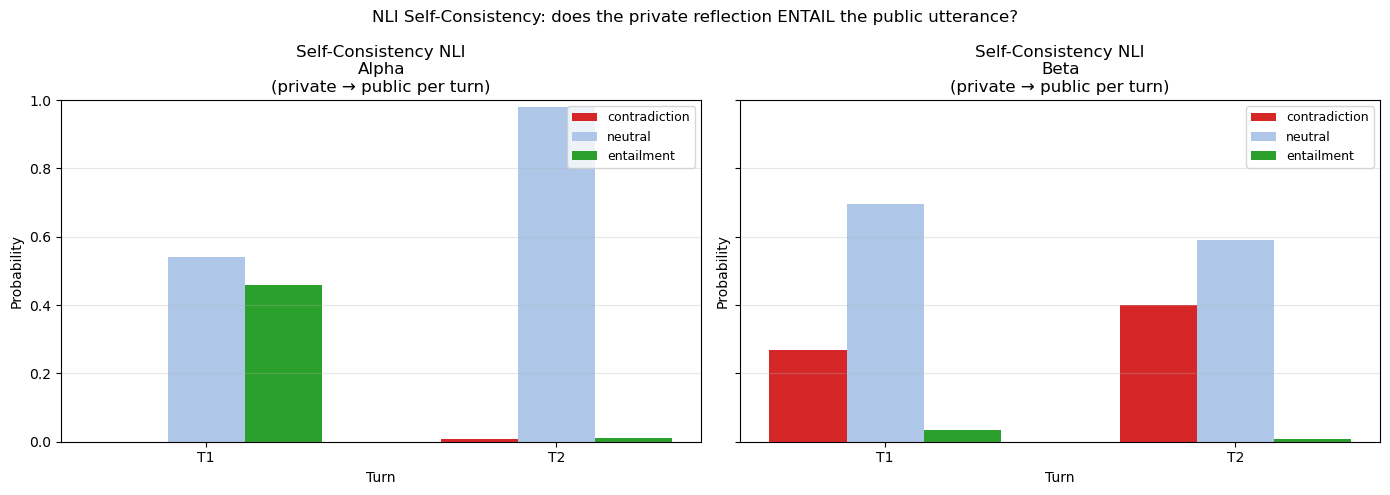

Computing NLI cross-agent public alignment distributions...


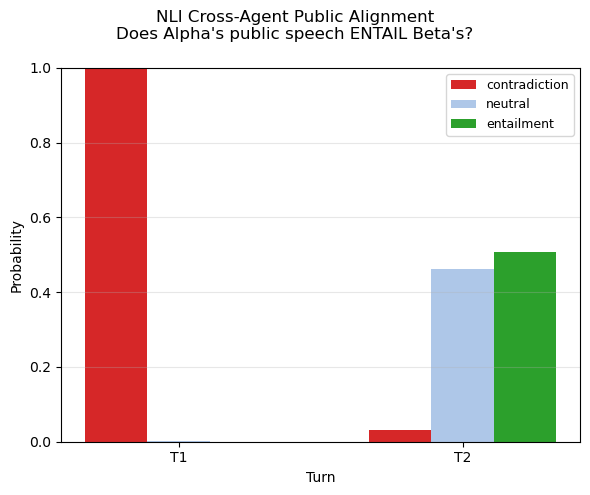

In [11]:
# ── 6. NLI full distribution analysis ────────────────────────────────────────
# Re-runs similarity on the same text pairs used by the semantic metrics,
# but shows the full 3-class NLI output (entailment / neutral / contradiction)
# per turn as grouped bar charts (3 thin bars per timestep).

import numpy as np
from agora.semantic_similarity_analyzer import (
    SemanticSimilarityAnalyzer,
    SEMANTIC_SIMILARITY_METHOD_NLI,
    PUBLIC_NARRATIVE_FIELD,
    PRIVATE_NARRATIVE_FIELD,
)

# Build NLI analyzer from the already-loaded debate history
structured_history = result.agora.structured_history()
nli_analyzer = SemanticSimilarityAnalyzer(
    structured_history,
    method=SEMANTIC_SIMILARITY_METHOD_NLI,
)

# Force model load once so we can call it directly
_ = nli_analyzer.model
id2label = nli_analyzer._id2label or {0: "contradiction", 1: "neutral", 2: "entailment"}

def _label_order(id2label):
    """Return (indices, labels) ordered as contradiction / neutral / entailment."""
    order = ["contradiction", "neutral", "entailment"]
    result_indices, result_labels = [], []
    for name in order:
        for idx, lab in id2label.items():
            if name in lab.lower():
                result_indices.append(int(idx))
                result_labels.append(lab)
                break
    return result_indices, result_labels

label_indices, label_names = _label_order(id2label)
colors = ["#d62728", "#aec7e8", "#2ca02c"]  # red=contradiction, blue=neutral, green=entailment


def _nli_distribution(text_a: str, text_b: str) -> list[float]:
    """Run forward + backward NLI and average the 3-class softmax distributions."""
    probs_ab = nli_analyzer.model.predict([(text_a, text_b)], apply_softmax=True)
    probs_ba = nli_analyzer.model.predict([(text_b, text_a)], apply_softmax=True)

    def _to_list(p):
        if hasattr(p, "tolist"):
            p = p.tolist()
        return p[0] if (isinstance(p, list) and isinstance(p[0], list)) else p

    ab = _to_list(probs_ab)
    ba = _to_list(probs_ba)

    return [(ab[i] + ba[i]) / 2.0 for i in range(len(ab))]


def _plot_nli_grouped(ax, turns, distributions, title):
    """Grouped bar chart: each turn has 3 thin bars (contradiction / neutral / entailment)."""

    x = np.arange(len(turns))
    width = 0.22  # thin bars

    for pos, (label_idx, label_name, color) in enumerate(
        zip(label_indices, label_names, colors)
    ):
        vals = np.array([distributions[t][label_idx] for t in range(len(turns))])
        offset = (pos - 1) * width  # positions: -width, 0, +width
        ax.bar(x + offset, vals, width=width, color=color, label=label_name)

    ax.set_xticks(x)
    ax.set_xticklabels([f"T{t}" for t in turns])
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Probability")
    ax.set_xlabel("Turn")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)


debate_data = nli_analyzer.debate_data
agent_ids = list(debate_data.keys())


# ── A: Self-consistency NLI (private → public, per agent) ────────────────────
print("Computing NLI self-consistency distributions...")

fig, axes = plt.subplots(1, len(agent_ids), figsize=(7 * len(agent_ids), 5), sharey=True)

if len(agent_ids) == 1:
    axes = [axes]

for ax, agent_id in zip(axes, agent_ids):
    turns_data = debate_data[agent_id]["debate_turns"]

    turns = [t.get("turn_num", i + 1) for i, t in enumerate(turns_data)]

    dists = [
        _nli_distribution(
            t[PRIVATE_NARRATIVE_FIELD],
            t[PUBLIC_NARRATIVE_FIELD],
        )
        for t in turns_data
    ]

    _plot_nli_grouped(
        ax,
        turns,
        dists,
        f"Self-Consistency NLI\n{agent_id}\n(private → public per turn)",
    )

fig.suptitle(
    "NLI Self-Consistency: does the private reflection ENTAIL the public utterance?",
    fontsize=12,
)

plt.tight_layout()
plt.show()


# ── B: Cross-agent public alignment NLI ──────────────────────────────────────
if len(agent_ids) >= 2:

    print("Computing NLI cross-agent public alignment distributions...")

    agent_a, agent_b = agent_ids[0], agent_ids[1]

    turns_a = {
        t.get("turn_num", i + 1): t
        for i, t in enumerate(debate_data[agent_a]["debate_turns"])
    }

    turns_b = {
        t.get("turn_num", i + 1): t
        for i, t in enumerate(debate_data[agent_b]["debate_turns"])
    }

    shared_turns = sorted(set(turns_a) & set(turns_b))

    dists = [
        _nli_distribution(
            turns_a[turn][PUBLIC_NARRATIVE_FIELD],
            turns_b[turn][PUBLIC_NARRATIVE_FIELD],
        )
        for turn in shared_turns
    ]

    fig, ax = plt.subplots(figsize=(max(6, len(shared_turns) * 1.5), 5))

    _plot_nli_grouped(ax, shared_turns, dists, "")

    fig.suptitle(
        f"NLI Cross-Agent Public Alignment\nDoes {agent_a}'s public speech ENTAIL {agent_b}'s?",
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()

Loading emotion model: SamLowe/roberta-base-go_emotions...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_3994186/3438365028.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _PALETTE  = cm.get_cmap("tab10", max(len(all_labels), 1))


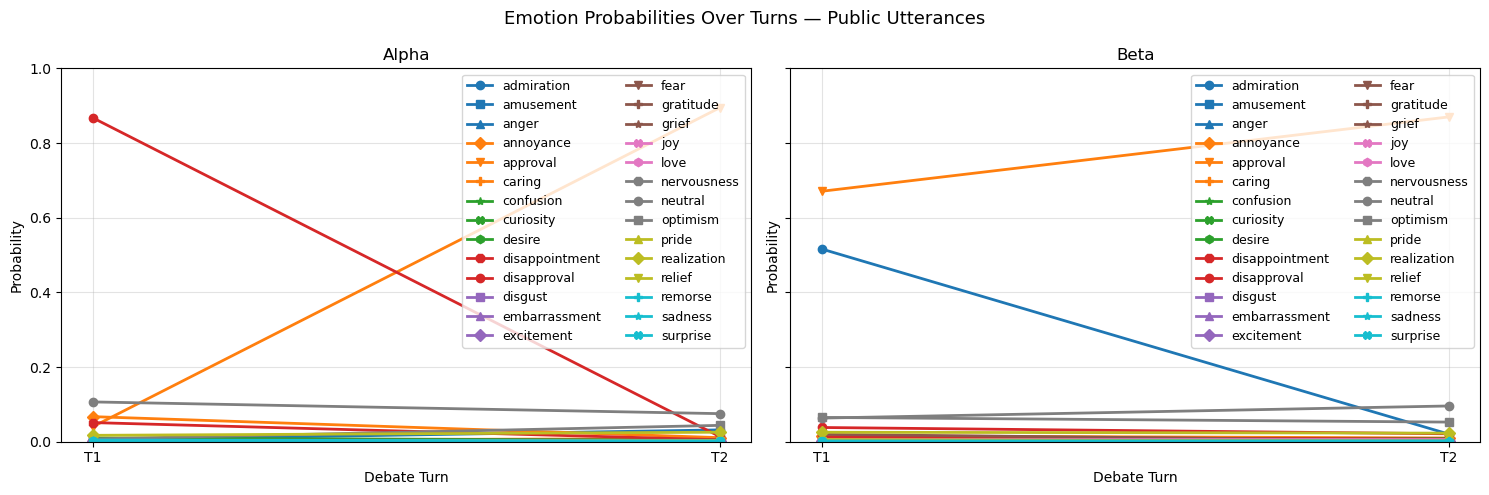

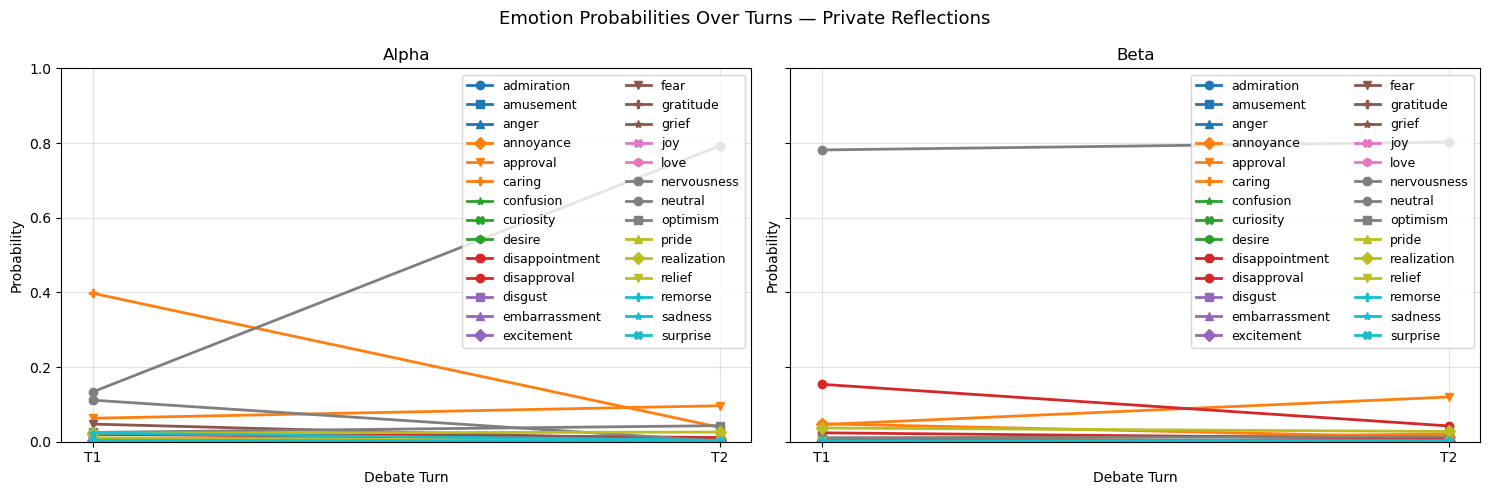

In [10]:
# ── 7. Emotion analysis ───────────────────────────────────────────────────────
# Uses SamLowe/roberta-base-go_emotions to score each agent's speech per turn.
# Legend colours and marker shapes are synced across ALL subplots and figures.

import matplotlib.cm as cm
from agora.emotion_analyzer import EmotionAnalyzer, PUBLIC_NARRATIVE_FIELD, PRIVATE_NARRATIVE_FIELD

structured_history = result.agora.structured_history()
emotion_analyzer = EmotionAnalyzer(structured_history)  # downloads model on first run

public_emotions  = emotion_analyzer.classify_field(PUBLIC_NARRATIVE_FIELD)
private_emotions = emotion_analyzer.classify_field(PRIVATE_NARRATIVE_FIELD)

# ── Build a shared style map keyed by emotion label ───────────────────────────
all_labels = sorted({
    label
    for field_result in (public_emotions, private_emotions)
    for agent_data in field_result.values()
    for label in agent_data.get("emotions", {}).keys()
})

_MARKERS = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "8"]
_PALETTE  = cm.get_cmap("tab10", max(len(all_labels), 1))
EMOTION_STYLE = {
    label: {"color": _PALETTE(i), "marker": _MARKERS[i % len(_MARKERS)]}
    for i, label in enumerate(all_labels)
}

# ── Plotting helper ───────────────────────────────────────────────────────────
def _plot_emotion_pair(field_results, alpha_name, beta_name, field_label):
    agent_ids = list(field_results.keys())
    alpha_id  = agent_ids[0]
    beta_id   = agent_ids[1] if len(agent_ids) > 1 else None

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    fig.suptitle(f"Emotion Probabilities Over Turns — {field_label}", fontsize=13)

    def _draw(ax, agent_id, agent_display_name):
        data     = field_results.get(agent_id, {})
        turns    = data.get("turns", [])
        emotions = data.get("emotions", {})
        if not turns or not emotions:
            ax.set_title(f"{agent_display_name}\n(no data)")
            return

        for label in all_labels:
            if label not in emotions:
                continue
            style = EMOTION_STYLE[label]
            ax.plot(
                turns,
                emotions[label],
                marker=style["marker"],
                color=style["color"],
                label=label,
                linewidth=2,
                markersize=6,
            )

        ax.set_xticks(turns)
        ax.set_xticklabels([f"T{t}" for t in turns])
        ax.set_xlabel("Debate Turn")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1.0)
        ax.set_title(agent_display_name)
        ax.legend(loc="upper right", fontsize=9, ncol=2)
        ax.grid(alpha=0.35)

    _draw(axes[0], alpha_id, alpha_name)
    if beta_id:
        _draw(axes[1], beta_id, beta_name)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

_plot_emotion_pair(public_emotions,  alpha_name, beta_name, "Public Utterances")
_plot_emotion_pair(private_emotions, alpha_name, beta_name, "Private Reflections")